# Session 10 — The Training Loop

**Take a small model and a real loop, and make it tell you the truth about itself.**

An 8.3M-parameter GPT, a byte-level BPE tokenizer and a corpus slice — all three
built in earlier sessions of this course — put through one honest training loop
and made to answer six questions about itself.

| # | the question | where it is answered |
|---|---|---|
| 1 | every tensor shape in the step, and what each dimension means | `experiments/e1_shapes.py` |
| 2 | one gradient verified by hand against `backward()` | `experiments/e2_grad_check.py` |
| 3 | gradient accumulation broken on purpose, both curves plotted | `experiments/e3_accumulation.py` |
| 4 | the grad norm at every step, and a step where it moved first | `experiments/e4_grad_norm.py` |
| 5 | my own MFU, and what is costing me the distance to 40% | `experiments/e5_mfu.py` |
| 6 | 0.1 in fp32, bf16 and fp8 E4M3, showing the bits | `experiments/e6_float_bits.py` |

Every number below is computed when this notebook runs. Nothing is quoted.

## 0. Setup

In [1]:
import sys, pathlib, json
ROOT = pathlib.Path.cwd()                # walk up if opened from a subdirectory
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from IPython.display import Markdown, Image, display

import torch
from src.report import machine
from src.loop import pick_device

def show(name):
    "Render an experiment's written-out findings inline."
    display(Markdown((ROOT / "results" / name).read_text()))

print(json.dumps(machine(), indent=2))
print("device the loop will use:", pick_device())

{
  "chip": "Apple M4",
  "platform": "macOS-26.5.1-arm64-arm-64bit-Mach-O",
  "python": "3.14.5",
  "torch": "2.13.0",
  "device": "mps"
}
device the loop will use: mps


### The data, the tokenizer and the model

The corpus slice is 1,052 documents of wikitext-2, source code and dialogue,
committed to this repository so a fresh clone reproduces every number here. The
tokenizer is the 10,000-id byte-level BPE built in session 2. Together they give
about 1.5M training tokens — small, real, and enough.

In [2]:
from src.data import load_documents, Sampler, VOCAB_SIZE, PAD_ID
from src.model import TinyGPT, Config

docs, lanes = load_documents(verbose=True)
print("vocab:", VOCAB_SIZE, "(10,000 BPE ids + one PAD)")

cfg = Config()
model = TinyGPT(cfg)
print(f"\n{cfg.n_layer} layers · d_model {cfg.d_model} · {cfg.n_head} heads · "
      f"d_ff {cfg.d_ff} · context {cfg.max_seq}")
print(f"parameters: {model.n_params():,} total, "
      f"{model.n_params(embeddings=False):,} non-embedding")

train        1261 docs  3,351,342 tokens
validation    100 docs    264,806 tokens
vocab: 10001 (10,000 BPE ids + one PAD)

4 layers · d_model 256 · 4 heads · d_ff 1024 · context 256
parameters: 8,336,384 total, 3,150,336 non-embedding


---
# 1. Every tensor shape in the step

A step touches four populations of tensors and it is easy to print only the
first: the activations, the loss scalars, the parameters *and their gradients*,
and the optimiser's per-weight state. The model narrates its own forward pass —
`forward(..., trace=[])` records every intermediate with a line saying what each
axis selects — so the table cannot drift away from the code that produced it.

In [3]:
import experiments.e1_shapes as e1
shapes = e1.main(verbose=False)
print(f"{len(shapes['activations'])} activation tensors traced, "
      f"every gradient shape matches its weight: {shapes['grad_shapes_match']}")
show("e1_shapes.md")

69 activation tensors traced, every gradient shape matches its weight: True


# Deliverable 1 — every tensor shape in one step

Model: 4 layers, d_model 256, 4 heads, d_ff 1024, vocab 10001, 8,336,384 parameters.

Step: micro-batch 8 rows × 4 accumulation steps = a global batch of 32 sequences and 4,055 valid tokens.

Micro-batch token counts this step: 899, 940, 995, 1,221 — different, because the sequences are different lengths. Deliverable 3 is about what that does.


## The axis names

| axis | what one index along it selects                                                                                       |
| ---- | --------------------------------------------------------------------------------------------------------------------- |
| B    | rows in one micro-batch -- what actually fits on the device                                                           |
| T    | positions in the sequence; micro-batch is padded to its own longest row, so T changes from micro-batch to micro-batch |
| D    | d_model, the width of the residual stream                                                                             |
| H    | attention heads                                                                                                       |
| Dh   | D/H, the slice of the channel one head owns                                                                           |
| F    | d_ff, the wide inner width of the MLP                                                                                 |
| V    | vocabulary size -- one score per token the model could name next                                                      |
| T_q  | the position doing the asking, in an attention score matrix                                                           |
| T_k  | the position being asked about                                                                                        |

## 1. Activations — one micro-batch, forward

(69 tensors, from token ids to logits. This micro-batch is B=8, T=192.)

| tensor              | shape       | dtype   |   elements | what each dimension means                                                                                                                                         |
| ------------------- | ----------- | ------- | ---------: | ----------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| inputs              | 8×192       | int64   |      1,536 | B=rows in the micro-batch, T=positions; each entry is a token id in [0, V)                                                                                        |
| mask                | 8×192       | bool    |      1,536 | B=rows, T=positions; True where the position holds a real token rather than padding                                                                               |
| tok_emb             | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; one learned vector per token id                                                                                                   |
| pos_emb             | 1×192×256   | float32 |     49,152 | 1=broadcast over rows, T=positions, D=d_model; one learned vector per absolute position                                                                           |
| resid_in            | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; the residual stream as it enters block 0                                                                                          |
| attn_bias           | 8×1×192×192 | float32 |    294,912 | B=rows, 1=broadcast over heads, T_q=querying position, T_k=attended position; 0 where the edge is allowed and -inf where it is not (future positions and padding) |
| block0.ln1          | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; the residual stream normalised per position before attention reads it                                                             |
| block0.attn.qkv     | 8×192×768   | float32 |  1,179,648 | B=rows in the micro-batch, T=positions, 3D=query, key and value packed into one projection so it is a single matmul                                               |
| block0.attn.q       | 8×4×192×64  | float32 |    393,216 | B=rows, H=attention heads, T=positions asking the question, Dh=d_model/H, the slice of the channel each head owns                                                 |
| block0.attn.k       | 8×4×192×64  | float32 |    393,216 | B=rows, H=heads, T=positions being asked about, Dh=per-head width                                                                                                 |
| block0.attn.v       | 8×4×192×64  | float32 |    393,216 | B=rows, H=heads, T=positions whose content gets carried, Dh=per-head width                                                                                        |
| block0.attn.scores  | 8×4×192×192 | float32 |  1,179,648 | B=rows, H=heads, T_q=querying position, T_k=attended position; entry (b,h,i,j) is how much position i wants position j                                            |
| block0.attn.weights | 8×4×192×192 | float32 |  1,179,648 | same axes as scores, now a distribution over T_k for each (row, head, T_q) -- each slice sums to 1                                                                |
| block0.attn.context | 8×4×192×64  | float32 |    393,216 | B=rows, H=heads, T=positions, Dh=per-head width; the value vectors averaged with the attention weights                                                            |
| block0.attn.merged  | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; the heads concatenated back into one channel axis                                                                                 |
| block0.attn.out     | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; attention's contribution to the residual stream                                                                                   |
| block0.resid_attn   | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; residual stream after attention has been added back                                                                               |
| block0.ln2          | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; residual stream normalised again before the MLP reads it                                                                          |
| block0.mlp.hidden   | 8×192×1024  | float32 |  1,572,864 | B=rows, T=positions, F=d_ff, the wide inner width where the per-position nonlinearity happens                                                                     |
| block0.mlp.out      | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; the MLP's contribution to the residual stream                                                                                     |
| block0.resid_mlp    | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; residual stream leaving this block                                                                                                |
| block1.ln1          | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; the residual stream normalised per position before attention reads it                                                             |
| block1.attn.qkv     | 8×192×768   | float32 |  1,179,648 | B=rows in the micro-batch, T=positions, 3D=query, key and value packed into one projection so it is a single matmul                                               |
| block1.attn.q       | 8×4×192×64  | float32 |    393,216 | B=rows, H=attention heads, T=positions asking the question, Dh=d_model/H, the slice of the channel each head owns                                                 |
| block1.attn.k       | 8×4×192×64  | float32 |    393,216 | B=rows, H=heads, T=positions being asked about, Dh=per-head width                                                                                                 |
| block1.attn.v       | 8×4×192×64  | float32 |    393,216 | B=rows, H=heads, T=positions whose content gets carried, Dh=per-head width                                                                                        |
| block1.attn.scores  | 8×4×192×192 | float32 |  1,179,648 | B=rows, H=heads, T_q=querying position, T_k=attended position; entry (b,h,i,j) is how much position i wants position j                                            |
| block1.attn.weights | 8×4×192×192 | float32 |  1,179,648 | same axes as scores, now a distribution over T_k for each (row, head, T_q) -- each slice sums to 1                                                                |
| block1.attn.context | 8×4×192×64  | float32 |    393,216 | B=rows, H=heads, T=positions, Dh=per-head width; the value vectors averaged with the attention weights                                                            |
| block1.attn.merged  | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; the heads concatenated back into one channel axis                                                                                 |
| block1.attn.out     | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; attention's contribution to the residual stream                                                                                   |
| block1.resid_attn   | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; residual stream after attention has been added back                                                                               |
| block1.ln2          | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; residual stream normalised again before the MLP reads it                                                                          |
| block1.mlp.hidden   | 8×192×1024  | float32 |  1,572,864 | B=rows, T=positions, F=d_ff, the wide inner width where the per-position nonlinearity happens                                                                     |
| block1.mlp.out      | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; the MLP's contribution to the residual stream                                                                                     |
| block1.resid_mlp    | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; residual stream leaving this block                                                                                                |
| block2.ln1          | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; the residual stream normalised per position before attention reads it                                                             |
| block2.attn.qkv     | 8×192×768   | float32 |  1,179,648 | B=rows in the micro-batch, T=positions, 3D=query, key and value packed into one projection so it is a single matmul                                               |
| block2.attn.q       | 8×4×192×64  | float32 |    393,216 | B=rows, H=attention heads, T=positions asking the question, Dh=d_model/H, the slice of the channel each head owns                                                 |
| block2.attn.k       | 8×4×192×64  | float32 |    393,216 | B=rows, H=heads, T=positions being asked about, Dh=per-head width                                                                                                 |
| block2.attn.v       | 8×4×192×64  | float32 |    393,216 | B=rows, H=heads, T=positions whose content gets carried, Dh=per-head width                                                                                        |
| block2.attn.scores  | 8×4×192×192 | float32 |  1,179,648 | B=rows, H=heads, T_q=querying position, T_k=attended position; entry (b,h,i,j) is how much position i wants position j                                            |
| block2.attn.weights | 8×4×192×192 | float32 |  1,179,648 | same axes as scores, now a distribution over T_k for each (row, head, T_q) -- each slice sums to 1                                                                |
| block2.attn.context | 8×4×192×64  | float32 |    393,216 | B=rows, H=heads, T=positions, Dh=per-head width; the value vectors averaged with the attention weights                                                            |
| block2.attn.merged  | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; the heads concatenated back into one channel axis                                                                                 |
| block2.attn.out     | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; attention's contribution to the residual stream                                                                                   |
| block2.resid_attn   | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; residual stream after attention has been added back                                                                               |
| block2.ln2          | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; residual stream normalised again before the MLP reads it                                                                          |
| block2.mlp.hidden   | 8×192×1024  | float32 |  1,572,864 | B=rows, T=positions, F=d_ff, the wide inner width where the per-position nonlinearity happens                                                                     |
| block2.mlp.out      | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; the MLP's contribution to the residual stream                                                                                     |
| block2.resid_mlp    | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; residual stream leaving this block                                                                                                |
| block3.ln1          | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; the residual stream normalised per position before attention reads it                                                             |
| block3.attn.qkv     | 8×192×768   | float32 |  1,179,648 | B=rows in the micro-batch, T=positions, 3D=query, key and value packed into one projection so it is a single matmul                                               |
| block3.attn.q       | 8×4×192×64  | float32 |    393,216 | B=rows, H=attention heads, T=positions asking the question, Dh=d_model/H, the slice of the channel each head owns                                                 |
| block3.attn.k       | 8×4×192×64  | float32 |    393,216 | B=rows, H=heads, T=positions being asked about, Dh=per-head width                                                                                                 |
| block3.attn.v       | 8×4×192×64  | float32 |    393,216 | B=rows, H=heads, T=positions whose content gets carried, Dh=per-head width                                                                                        |
| block3.attn.scores  | 8×4×192×192 | float32 |  1,179,648 | B=rows, H=heads, T_q=querying position, T_k=attended position; entry (b,h,i,j) is how much position i wants position j                                            |
| block3.attn.weights | 8×4×192×192 | float32 |  1,179,648 | same axes as scores, now a distribution over T_k for each (row, head, T_q) -- each slice sums to 1                                                                |
| block3.attn.context | 8×4×192×64  | float32 |    393,216 | B=rows, H=heads, T=positions, Dh=per-head width; the value vectors averaged with the attention weights                                                            |
| block3.attn.merged  | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; the heads concatenated back into one channel axis                                                                                 |
| block3.attn.out     | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; attention's contribution to the residual stream                                                                                   |
| block3.resid_attn   | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; residual stream after attention has been added back                                                                               |
| block3.ln2          | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; residual stream normalised again before the MLP reads it                                                                          |
| block3.mlp.hidden   | 8×192×1024  | float32 |  1,572,864 | B=rows, T=positions, F=d_ff, the wide inner width where the per-position nonlinearity happens                                                                     |
| block3.mlp.out      | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; the MLP's contribution to the residual stream                                                                                     |
| block3.resid_mlp    | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; residual stream leaving this block                                                                                                |
| ln_f                | 8×192×256   | float32 |    393,216 | B=rows, T=positions, D=d_model; residual stream normalised one last time before the output head                                                                   |
| logits              | 8×192×10001 | float32 | 15,361,536 | B=rows, T=positions, V=vocab size; an unnormalised score for every token the model could name next, at every position                                             |
| per_token_loss      | 1536        | float32 |      1,536 | B*T=every position in the micro-batch flattened; the cross entropy of the true next token at that position, zeroed wherever the mask says there is no target      |

## 2. The scalars

| tensor                      | shape | dtype   | meaning                                                                                                                         |
| --------------------------- | ----- | ------- | ------------------------------------------------------------------------------------------------------------------------------- |
| loss_sum (per micro-batch)  | ()    | float32 | the summed cross entropy of one micro-batch -- a scalar with no dimensions, which is the whole point: one number for 899 tokens |
| loss (step, token-weighted) | ()    | float32 | loss_sum over all micro-batches divided by the total valid tokens in the global batch (4,055)                                   |
| grad_norm                   | ()    | float32 | one L2 norm over every gradient in the model concatenated -- the single number section 12 says to watch                         |

## 3. Parameters, and the gradient of each

| parameter                 | shape     |  elements | grad shape | same? | what each dimension means                                                            |
| ------------------------- | --------- | --------: | ---------- | ----- | ------------------------------------------------------------------------------------ |
| tok_emb.weight            | 10001×256 | 2,560,256 | 10001×256  | yes   | V=one row per token id, D=the vector it maps to                                      |
| pos_emb.weight            | 256×256   |    65,536 | 256×256    | yes   | T_max=one row per absolute position, D=the vector added to whatever token sits there |
| blocks.0.ln1.weight       | 256       |       256 | 256        | yes   | D=one gain per channel                                                               |
| blocks.0.ln1.bias         | 256       |       256 | 256        | yes   | D=one shift per channel                                                              |
| blocks.0.attn.qkv.weight  | 768×256   |   196,608 | 768×256    | yes   | 3D=query, key and value stacked, D=input width                                       |
| blocks.0.attn.proj.weight | 256×256   |    65,536 | 256×256    | yes   | D=output width back into the residual stream, D=concatenated head width in           |
| blocks.0.ln2.weight       | 256       |       256 | 256        | yes   | D=one gain per channel                                                               |
| blocks.0.ln2.bias         | 256       |       256 | 256        | yes   | D=one shift per channel                                                              |
| blocks.0.mlp.fc.weight    | 1024×256  |   262,144 | 1024×256   | yes   | F=d_ff out, D=d_model in                                                             |
| blocks.0.mlp.out.weight   | 256×1024  |   262,144 | 256×1024   | yes   | D=d_model out, F=d_ff in                                                             |
| blocks.1.ln1.weight       | 256       |       256 | 256        | yes   | D=one gain per channel                                                               |
| blocks.1.ln1.bias         | 256       |       256 | 256        | yes   | D=one shift per channel                                                              |
| blocks.1.attn.qkv.weight  | 768×256   |   196,608 | 768×256    | yes   | 3D=query, key and value stacked, D=input width                                       |
| blocks.1.attn.proj.weight | 256×256   |    65,536 | 256×256    | yes   | D=output width back into the residual stream, D=concatenated head width in           |
| blocks.1.ln2.weight       | 256       |       256 | 256        | yes   | D=one gain per channel                                                               |
| blocks.1.ln2.bias         | 256       |       256 | 256        | yes   | D=one shift per channel                                                              |
| blocks.1.mlp.fc.weight    | 1024×256  |   262,144 | 1024×256   | yes   | F=d_ff out, D=d_model in                                                             |
| blocks.1.mlp.out.weight   | 256×1024  |   262,144 | 256×1024   | yes   | D=d_model out, F=d_ff in                                                             |
| blocks.2.ln1.weight       | 256       |       256 | 256        | yes   | D=one gain per channel                                                               |
| blocks.2.ln1.bias         | 256       |       256 | 256        | yes   | D=one shift per channel                                                              |
| blocks.2.attn.qkv.weight  | 768×256   |   196,608 | 768×256    | yes   | 3D=query, key and value stacked, D=input width                                       |
| blocks.2.attn.proj.weight | 256×256   |    65,536 | 256×256    | yes   | D=output width back into the residual stream, D=concatenated head width in           |
| blocks.2.ln2.weight       | 256       |       256 | 256        | yes   | D=one gain per channel                                                               |
| blocks.2.ln2.bias         | 256       |       256 | 256        | yes   | D=one shift per channel                                                              |
| blocks.2.mlp.fc.weight    | 1024×256  |   262,144 | 1024×256   | yes   | F=d_ff out, D=d_model in                                                             |
| blocks.2.mlp.out.weight   | 256×1024  |   262,144 | 256×1024   | yes   | D=d_model out, F=d_ff in                                                             |
| blocks.3.ln1.weight       | 256       |       256 | 256        | yes   | D=one gain per channel                                                               |
| blocks.3.ln1.bias         | 256       |       256 | 256        | yes   | D=one shift per channel                                                              |
| blocks.3.attn.qkv.weight  | 768×256   |   196,608 | 768×256    | yes   | 3D=query, key and value stacked, D=input width                                       |
| blocks.3.attn.proj.weight | 256×256   |    65,536 | 256×256    | yes   | D=output width back into the residual stream, D=concatenated head width in           |
| blocks.3.ln2.weight       | 256       |       256 | 256        | yes   | D=one gain per channel                                                               |
| blocks.3.ln2.bias         | 256       |       256 | 256        | yes   | D=one shift per channel                                                              |
| blocks.3.mlp.fc.weight    | 1024×256  |   262,144 | 1024×256   | yes   | F=d_ff out, D=d_model in                                                             |
| blocks.3.mlp.out.weight   | 256×1024  |   262,144 | 256×1024   | yes   | D=d_model out, F=d_ff in                                                             |
| ln_f.weight               | 256       |       256 | 256        | yes   | D=one gain per channel                                                               |
| ln_f.bias                 | 256       |       256 | 256        | yes   | D=one shift per channel                                                              |
| head.weight               | 10001×256 | 2,560,256 | 10001×256  | yes   | V=one row per output token, D=the direction in the residual stream that votes for it |

Every gradient has the shape of its weight: 8,336,384 gradient numbers for 8,336,384 weights. That is the definition from section 2 — a gradient belongs to one weight.


## 4. What the optimiser keeps, per weight

| state tensor                      | shape     |  elements | meaning                                                       |
| --------------------------------- | --------- | --------: | ------------------------------------------------------------- |
| tok_emb.weight :: exp_avg         | 10001×256 | 2,560,256 | the same shape as the weight -- one running number per weight |
| tok_emb.weight :: exp_avg_sq      | 10001×256 | 2,560,256 | the same shape as the weight -- one running number per weight |
| pos_emb.weight :: exp_avg         | 256×256   |    65,536 | the same shape as the weight -- one running number per weight |
| pos_emb.weight :: exp_avg_sq      | 256×256   |    65,536 | the same shape as the weight -- one running number per weight |
| blocks.0.ln1.weight :: exp_avg    | 256       |       256 | the same shape as the weight -- one running number per weight |
| blocks.0.ln1.weight :: exp_avg_sq | 256       |       256 | the same shape as the weight -- one running number per weight |

AdamW holds 16,672,768 extra numbers for 8,336,384 weights — exactly two per weight. With a bf16 weight (2 B), a bf16 gradient (2 B), an fp32 master copy (4 B) and these two fp32 moments (8 B), that is the 16 bytes per weight of section 13: 127.2 MiB of training state for this model, before a single activation is stored.


---
# 2. One gradient, verified by hand

Nudge a weight, measure how the loss changed, compare against what `backward()`
reported. First on the session's own four-link chain where the answer is 64
exactly, then on one weight of the real 8.3M-parameter model.

In [4]:
# the chain from section 4, done the way a person would do it
x, t, w1, w2 = 2.0, 20.0, 3.0, 4.0
h = w1 * x
y = w2 * h
loss = (y - t) ** 2
print(f"h = {h}   y = {y}   loss = {loss}")

dL_dy  = 2 * (y - t)
dL_dw2 = dL_dy * h
dL_dh  = dL_dy * w2
dL_dw1 = dL_dh * x
print(f"dL/dy = {dL_dy}   dL/dw2 = {dL_dw2}   dL/dh = {dL_dh}   dL/dw1 = {dL_dw1}")

eps = 1e-6
nudged = ((w2 * ((w1 + eps) * x) - t) ** 2 - (w2 * ((w1 - eps) * x) - t) ** 2) / (2 * eps)
a = torch.tensor(w1, dtype=torch.float64, requires_grad=True)
((w2 * (a * x)) - t).pow(2).backward()
print(f"\nby hand      {dL_dw1:.12f}")
print(f"by nudging   {nudged:.12f}")
print(f"by backward  {float(a.grad):.12f}")

h = 6.0   y = 24.0   loss = 16.0
dL/dy = 8.0   dL/dw2 = 48.0   dL/dh = 32.0   dL/dw1 = 64.0

by hand      64.000000000000
by nudging   64.000000008058
by backward  64.000000000000


real model, float64: backward() -0.004117679113
                     nudge      -0.004117679087
                     agreement  10.6 decimal places


# Deliverable 2 — verify one gradient by hand

## A. The session's own chain, where the answer is known

`x = 2`, `w1 = 3`, `w2 = 4`, `target = 20`.

| quantity      | calculation | value |
| ------------- | ----------- | ----: |
| h = w1·x      | 3 × 2       |     6 |
| y = w2·h      | 4 × 6       |    24 |
| loss = (y−t)² | (24 − 20)²  |    16 |

Walking back one link at a time:

| quantity | calculation | value |
| -------- | ----------- | ----: |
| ∂L/∂y    | 2(y − t)    |     8 |
| ∂L/∂w2   | ∂L/∂y × h   |    48 |
| ∂L/∂h    | ∂L/∂y × w2  |    32 |
| ∂L/∂w1   | ∂L/∂h × x   |    64 |

| ∂L/∂w1 obtained       |           value |
| --------------------- | --------------: |
| by hand (chain rule)  | 64.000000000000 |
| by nudging (h = 1e-6) | 64.000000008058 |
| by backward()         | 64.000000000000 |

Hand vs `backward()`: identical to every digit float64 has (difference exactly 0). Hand vs nudge: 8.1 decimals — the nudge is the one that is approximate.


## B. One weight of the real model, in float64

Weight: `blocks.0.mlp.fc.weight[17, 42]` = -0.0124816364, on a fixed batch of 2×96 tokens. Loss at that point: 9.3029963979.

`backward()` reported **-0.004117679113**.

| nudge h |      loss(w+h) |      loss(w−h) |    (Δloss)/2h | rel. error | decimals agreed |
| ------: | -------------: | -------------: | ------------: | ---------: | --------------: |
|   1e-01 | 9.302611659054 | 9.303429750377 | -0.0040904566 |   6.61e-03 |             4.6 |
|   1e-02 | 9.302955468124 | 9.303037816216 | -0.0041174046 |   6.67e-05 |             6.6 |
|   1e-03 | 9.302992282696 | 9.303000518048 | -0.0041176764 |   6.67e-07 |             8.6 |
|   1e-04 | 9.302995986186 | 9.302996809722 | -0.0041176791 |   6.50e-09 |            10.6 |
|   1e-05 | 9.302996356753 | 9.302996439106 | -0.0041176792 |   1.51e-08 |            10.2 |
|   1e-06 | 9.302996393812 | 9.302996402047 | -0.0041176786 |   1.14e-07 |             9.3 |
|   1e-07 | 9.302996397518 | 9.302996398341 | -0.0041176751 |   9.77e-07 |             8.4 |
|   1e-08 | 9.302996397888 | 9.302996397971 | -0.0041176840 |   1.18e-06 |             8.3 |

Best at h = 1e-04: the nudge says -0.004117679087, `backward()` says -0.004117679113. They agree to **10.6 decimal places** (relative error 6.50e-09).


Four more weights, one nudge each at h = 1e-5, to show the first was not a lucky pick:

| weight                            |    backward() |         nudge | rel. error | decimals |
| --------------------------------- | ------------: | ------------: | ---------: | -------: |
| tok_emb.weight[293, 100]          | -0.0154110461 | -0.0154110462 |    4.5e-09 |     10.2 |
| blocks.2.attn.qkv.weight[300, 11] |  0.0000276442 |  0.0000276443 |    2.3e-06 |     10.2 |
| head.weight[4096, 200]            | -0.0000171628 | -0.0000171628 |    4.4e-08 |     12.1 |
| ln_f.weight[64]                   | -0.0047538565 | -0.0047538564 |    1.5e-08 |     10.2 |

## C. The same check in float32, which fails — and why

Identical model, identical batch, identical weight, only the dtype changed. `backward()` reports -0.0041176705; the best nudge manages -0.0041325887 at h = 1e-02 — **4.8 decimals**, against 10.6 in float64.

| nudge h |  (Δloss)/2h | rel. error | decimals agreed |
| ------: | ----------: | ---------: | --------------: |
|   1e-01 | -0.00409126 |   6.41e-03 |             4.6 |
|   1e-02 | -0.00413259 |   3.62e-03 |             4.8 |
|   1e-03 | -0.00381470 |   7.36e-02 |             3.5 |
|   1e-04 | -0.00635783 |   5.44e-01 |             2.6 |
|   1e-05 |  0.00000000 |   1.00e+00 |             2.4 |
|   1e-06 | -0.31789144 |   7.62e+01 |             0.5 |
|   1e-07 |  0.00000000 |   1.00e+00 |             2.4 |
|   1e-08 |  0.00000000 |   1.00e+00 |             2.4 |

This is the disagreement the assignment says is worth understanding, and the thing worth understanding is that **`backward()` is not the one that is wrong**. The loss here is around 9.3030; float32 resolves it to about 5.55e-07. Dividing that noise by 2h magnifies it as h shrinks, while the truncation error of the central difference shrinks as h². The two meet at a floor, and no choice of h gets under it. In float64 the same floor sits eight orders of magnitude lower, which is why the check has to be run there.

The practical rule: a finite-difference gradient check that fails in float32 has told you nothing. Re-run it in float64 before you go looking for a bug in the backward pass.


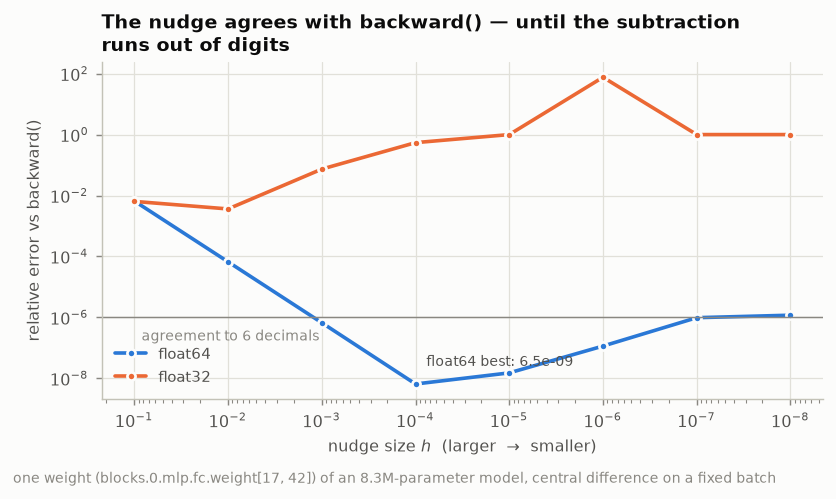

In [5]:
import experiments.e2_grad_check as e2
grad = e2.main(verbose=False)
best = grad["float64"]["best"]
print(f"real model, float64: backward() {grad['float64']['backward_reported']:.12f}")
print(f"                     nudge      {best['finite_difference']:.12f}")
print(f"                     agreement  {best['decimals']:.1f} decimal places")
show("e2_grad_check.md")
display(Image(filename=str(ROOT / "results" / "e2_grad_check.png")))

---
# 3. Gradient accumulation, broken on purpose

Average the averages with micro-batches of different lengths, and plot both
curves together. The micro-batches here are length-bucketed, which is what a
real loader does for throughput and also the setting in which the bug bites
hardest.

In [6]:
# section 8's arithmetic, computed
micro = [(4, 2.0), (4, 2.0), (2, 5.0)]      # (valid tokens, average loss)
correct = sum(n * l for n, l in micro) / sum(n for n, _ in micro)
wrong   = sum(l for _, l in micro) / len(micro)
print(f"token-weighted      {correct:.4f}")
print(f"average of averages {wrong:.4f}")
print(f"error               {100*(wrong-correct)/correct:.1f}%")

token-weighted      2.6000
average of averages 3.0000
error               15.4%


running the paired training runs (4 runs total)


  [bucketed/token_weighted] 400 steps ...


  [bucketed/mean_of_means] 400 steps ...


  [equal-length/token_weighted] 400 steps ...


  [equal-length/mean_of_means] 400 steps ...


one step, same weights, same micro-batches:
  reported loss differs by -0.08%
  the two gradients differ by 17.26% and point 8.37deg apart

after 400 steps: gap +0.0389 nats, control +0.0000 nats


# Deliverable 3 — breaking gradient accumulation on purpose

## 1. The arithmetic, computed rather than quoted

| micro-batch | valid tokens | average loss |
| ----------: | -----------: | -----------: |
|           1 |            4 |          2.0 |
|           2 |            4 |          2.0 |
|           3 |            2 |          5.0 |

- token-weighted (correct): **2.6000**
- average of the averages: **3.0000**
- error: **15.4%**

Set every token count to 4 and the two agree exactly (3.0000 vs 3.0000). That is the whole reason it survived in shipping frameworks.


## 2. One real step — the gradients, not just the number

Four length-bucketed micro-batches holding 1,280, 656, 1,432, 280 valid tokens (a 5.1× spread), through the same model at the same weights:

| quantity         | sum ÷ sum of tokens | average of averages | difference |
| ---------------- | ------------------: | ------------------: | ---------: |
| reported loss    |            9.285668 |            9.278541 |     -0.08% |
| gradient L2 norm |            5.874394 |            5.361083 |     -8.74% |

The reported number being wrong is the visible half. The half that actually
matters is that the two gradient vectors are not the same vector:

- cosine similarity **0.989360** — an angle of
  **8.37°** between them
- relative L2 difference **17.26%** of the
  correct gradient's own norm

The optimiser is being pointed somewhere else, not merely told the wrong
distance. Clipping does not rescue this: clipping rescales the length and
leaves the direction exactly as it was.


## 3. Two runs, identical but for the division

400 steps, micro-batch 8 × 4 accumulation, AdamW at 3e-4 with 20 warmup steps, clip 1.0, same seed, same initial weights, same batches in the same order. Both runs are scored on one common token-weighted validation set, so the metric does not move with the thing it measures.

The control arm holds every sequence to 91 tokens — the geometric mean of the bucketed arm's 32-256 range — so it sees the same token budget per micro-batch on average and differs in one thing only: there is no spread between micro-batches for the bug to key on.

| setting                                       | correct | broken | gap (nats) | relative |
| --------------------------------------------- | ------: | -----: | ---------: | -------: |
| micro-batches of different lengths (bucketed) |  4.5150 | 4.5540 |    +0.0389 |   +0.86% |
| control: every micro-batch 91 tokens long     |  4.5560 | 4.5560 |    +0.0000 |   +0.00% |

![gradient accumulation](e3_accumulation.png)

The left panel is the gap — plotted from step 80 because the opening
descent from 7.6 to 4.7 nats would otherwise squash it flat, which is precisely
how a gap this size stays invisible on a real dashboard. The middle panel is the
identical experiment with the token counts made equal, where the gap is
+0.0000 nats: the bug hiding, reproduced. The right panel is the
difference between the two curves in each setting, which is the only view where
neither of them can be mistaken for the other.

**The most uncomfortable number in this whole deliverable is a small one.** The
loss the broken run *printed* was wrong by only -0.33% on average
over the 400 steps — well inside the step-to-step noise of any real dashboard
and, at every single step, entirely plausible. Meanwhile the gradient it fed the
optimiser was 17.3% off and pointing
8.4° away. The printed number is nearly innocent while the
training is wrong. That asymmetry is the reason this bug survived in shipping
frameworks until 2024, and it is the reason to check the reduction directly
instead of watching the curve.

**A note on scale.** +0.0389 nats after 400 steps on an 8.3M model
is small, and I am not going to inflate it. What makes it worth the section is
that it is (a) exactly reproducible, (b) exactly zero in the control, and (c) a
*systematic* bias rather than noise — it is the same wrong direction on every
step of a run that would go on for weeks, on micro-batches whose token counts in
production vary far more than the 5.1×
here.


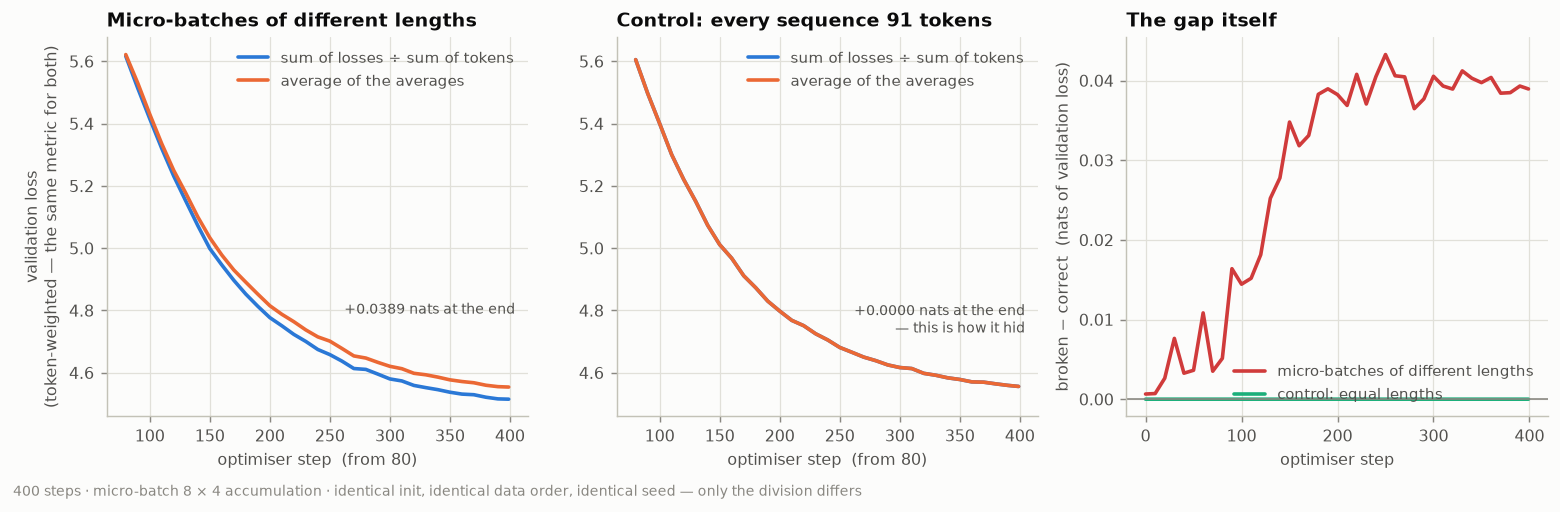

In [7]:
import experiments.e3_accumulation as e3
accum = e3.main(verbose=False)          # four training runs; a few minutes
c = accum["one_step"]["comparison"]
print(f"one step, same weights, same micro-batches:")
print(f"  reported loss differs by {c['reported_loss_error_pct']:+.2f}%")
print(f"  the two gradients differ by {100*c['relative_l2_difference']:.2f}% "
      f"and point {c['angle_degrees']:.2f}deg apart")
print(f"\nafter {accum['steps']} steps: gap {accum['gap_bucketed']:+.4f} nats, "
      f"control {accum['gap_fixed']:+.4f} nats")
show("e3_accumulation.md")
display(Image(filename=str(ROOT / "results" / "e3_accumulation.png")))

---
# 4. The grad norm, at every step

Logged before clipping, every step, alongside a fixed held-out probe loss
evaluated after every step — so the loss trace moves only when the model moves,
not when the batch happens to be hard.

train lanes: 492 wiki docs, 400 code docs


running arm 'cap off' ...


  [cap off] step    0  |g|    2.132  probe 9.2419


  [cap off] step   60  |g|    0.517  probe 6.4368


  [cap off] step  120  |g|    0.667  probe 6.2352


...

  [cap 1.0] step  240  |g|    0.836  probe 6.1635


  [cap 1.0] step  300  |g|   10.572  probe 6.1112


  [cap 1.0] step  360  |g|    0.680  probe 6.0826


injected anomaly at step 300: norm z = 72.1 sigma, probe loss crossed at step 300 (0 steps of warning)
unprompted: norm crossed at step 345 (5.5 sigma), loss at 407 -- 62 steps early


# Deliverable 4 — the grad norm, logged every step

420 steps, micro-batch 8 × 4 accumulation, wiki lane only. Logged every step: the global gradient L2 norm **before** clipping, the clip scale, the training loss, and a probe loss on a fixed held-out set of 4,096 tokens evaluated after the optimiser step.


## 1. Unprompted — the step the detector found on its own


This is the deliverable, and it was not arranged. Across the 420 steps of
the uncapped arm, 1 steps crossed 5-sigma on the gradient norm.
1 of them was followed by a
5-sigma crossing of the probe loss at a **later** step.

The clearest is **step 345**. The gradient norm went to
1.405 — 5.5 sigma away from its own recent
behaviour — while the probe loss stayed inside its noise band. The probe did not
cross until step 407: **62 steps later**. Anyone
watching only the loss had 62 steps of a run that looked
completely healthy, and by the time the loss moved, the batches responsible had
been gone for 62 steps.

| norm crossed at |  norm |   z | loss crossed at |   z | lead (steps) |
| --------------: | ----: | --: | --------------: | --: | -----------: |
|             345 | 1.405 | 5.5 |             407 | 5.0 |          +62 |

## 2. The controlled case — where the loss never finds out at all

At step 300 the run is handed one global batch of real source code — a lane this model has never seen — and then goes straight back to wiki. Nothing else changes. This is a data contamination: the kind of thing a mixture bug does quietly.

|                                                      | cap off | cap 1.0 |
| ---------------------------------------------------- | ------: | ------: |
| gradient norm at the anomalous step                  |  10.765 |  10.572 |
| its z-score against the previous 25 steps            |    72.1 |    82.2 |
| clip scale applied                                   |   1.000 |   0.095 |
| first step the probe loss crossed 5 sigma afterwards |     300 |     301 |
| the probe loss's own z-score there                   |   -10.1 |    -8.1 |
| warning the norm gave                                | 0 steps | 1 steps |

The gradient norm registered the contaminated batch at
**72 sigma** — the largest excursion
anywhere in the run, 13x
the median norm.

The probe loss crossed at step 300:
**0 steps of warning**.
The batch responsible was gone by then — one step of code in a run of wiki — so
whatever diagnosis was going to happen had to start from the norm, because by
the time the loss reacted the evidence was
0 steps in the past.

Worth saying plainly: the probe's reaction was
a *fall* of 10 sigma.
An out-of-distribution batch does not have to make the loss worse to have
damaged the run, and a one-sided alarm would have missed it entirely. That is
not a hypothetical — the first version of this experiment tested only for the
loss rising, reported "never", and was wrong.

The right column is the cap engaging on the same batch: every gradient scaled by
**0.095**, a
11x reduction, with the direction left
exactly as it was. Note that the norm is measured *before* the cap, which is why
the capped arm still reports the full
82 sigma. Logged after clipping it
would sit pinned at the threshold and tell you nothing — a small detail that is
the difference between a useful trace and a flat line.

(The two arms report slightly different norms at step 300 because
clipping changed the trajectory earlier in the run; it is the same batch through
two models that have already diverged.)


![grad norm](e4_grad_norm.png)

Left: the injected anomaly, uncapped. Middle: the same batch with the cap on.
Right: step
345, which nobody arranged.

Both traces are drawn on one axis as robust z-scores against their own previous
25 steps. That is the only honest way to put a loss in nats and a norm in
gradient units on one plot: a second y-axis would let me slide one curve against
the other until the story looked however I wanted it to.

## 3. What the trace costs, and where the cap should go

The grad norm is one sum of squares over tensors that are already in memory and
that the optimiser is about to read anyway: **2.20 ms**, against a median step of 223 ms — 0.99% of the clock. It is the cheapest trace on the dashboard and the only one that is ever
early. The loss answers *is it learning*; the norm answers *is it about to
stop*.

For V5 that settles three things. Log the norm from step one. Clip from step
one. And choose the threshold from the norm's own distribution rather than from
habit: in this run the median norm was
0.814, the 99th percentile
1.994, and the
contaminated batch 10.8. A cap of 1.0 sits at the
82th
percentile — it clips a fifth of ordinary steps, which is more than I would want
on a real run. On this evidence I would set it nearer
2.0: high enough to
leave normal steps alone, low enough that the step-300 batch is still
cut by 5x.
That is a number chosen from data, which is the whole ask.


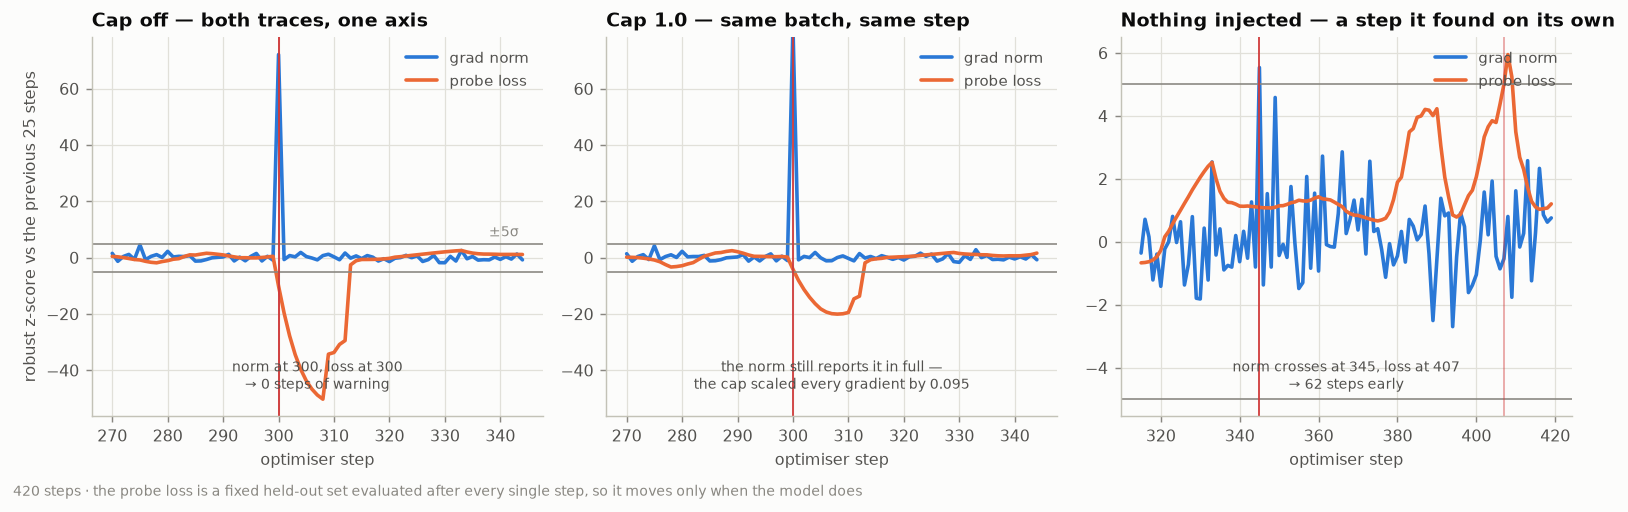

In [8]:
import experiments.e4_grad_norm as e4
norms = e4.main(verbose=False)          # two 420-step runs; a few minutes
inj = norms["injected"]
print(f"injected anomaly at step {norms['inject_at']}: "
      f"norm z = {inj['grad_norm_z']:.1f} sigma, "
      f"probe loss crossed at step {inj['loss_crossing_step']} "
      f"({inj['lead_steps']} steps of warning)")
if norms["headline_event"]:
    h = norms["headline_event"]
    print(f"unprompted: norm crossed at step {h['grad_norm_step']} "
          f"({h['grad_norm_z']:.1f} sigma), loss at {h['loss_step']} "
          f"-- {h['lead_steps']} steps early")
show("e4_grad_norm.md")
display(Image(filename=str(ROOT / "results" / "e4_grad_norm.png")))

---
# 6. 0.1 in fp32, bf16 and fp8 E4M3

Derived by hand in exact rational arithmetic, then checked against the bits the
hardware actually stores. (Out of order on purpose: deliverable 5 measures
throughput and has to run last, with nothing else competing for the device.)

In [9]:
from src.floats import FP32, BF16, FP8_E4M3, encode, binary_expansion, torch_bits

print("0.1 in binary:", binary_expansion(0.1, 28))
print()
for fmt, dt in ((FP32, torch.float32), (BF16, torch.bfloat16),
                (FP8_E4M3, torch.float8_e4m3fn)):
    e = encode(0.1, fmt)
    hw = torch_bits(0.1, dt)
    print(f"{fmt.name:9} {e.bits:34} {e.hex:>10}  "
          f"= {float(e.value):.12f}  rel err {float(e.rel_error):.2e}  "
          f"matches hardware: {hw == e.bits_flat}")

0.1 in binary: 0.0001100110011001100110011001…

fp32      0 01111011 10011001100110011001101 0x3DCCCCCD  = 0.100000001490  rel err 1.49e-08  matches hardware: True
bf16      0 01111011 1001101                     0x3DCD  = 0.100097656250  rel err 9.77e-04  matches hardware: True
fp8 E4M3  0 0011 101                               0x1D  = 0.101562500000  rel err 1.56e-02  matches hardware: True


measured on this session's own run: 51.6% of 8,336,384 weight updates would round to nothing in bare bf16 (91.4% in fp8 E4M3)


# Deliverable 6 — 0.1 in fp32, bf16 and fp8 E4M3

## Doing it by hand

0.1 is not a binary fraction. Doubling and reading off the carry gives

```
0.1  =  0.0001100110011001100110011001…  (binary)
     =  1.100110011001100110011…  ×  2⁻⁴
```

so the unbiased exponent is **−4** in every format below, and the significand to be rounded is always the same repeating `1.10011001100…`. Only the number of mantissa bits and the exponent bias change.


### fp32 — 1 sign, 8 exponent, 23 mantissa (bias 127)

- exponent field = −4 + 127 = **123** = `01111011`
- mantissa = the 23 bits after the leading 1 of `1.10011001100…`, rounded to nearest (the first discarded bit is a 1 and the tail is non-zero, so it rounds up) = `10011001100110011001101`
- significand = `1.10011001100110011001101`₂ = 1.6000000238

```
0 01111011 10011001100110011001101     0x3DCCCCCD
^ ^------- ^----------------------
| exponent    mantissa
sign
```

- stored value = **0.10000000149011611938**
- relative error = **1.490e-08** (0.0000%)
- torch stores `00111101110011001100110011001101` — **identical**


### bf16 — 1 sign, 8 exponent, 7 mantissa (bias 127)

- exponent field = −4 + 127 = **123** = `01111011`
- mantissa = the 7 bits after the leading 1 of `1.10011001100…`, rounded to nearest (the first discarded bit is a 1 and the tail is non-zero, so it rounds up) = `1001101`
- significand = `1.1001101`₂ = 1.6015625000

```
0 01111011 1001101     0x3DCD
^ ^------- ^------
| exponent    mantissa
sign
```

- stored value = **0.10009765625000000000**
- relative error = **9.766e-04** (0.0977%)
- torch stores `0011110111001101` — **identical**


### fp8 E4M3 — 1 sign, 4 exponent, 3 mantissa (bias 7)

- exponent field = −4 + 7 = **3** = `0011`
- mantissa = the 3 bits after the leading 1 of `1.10011001100…`, rounded to nearest (the first discarded bit is a 1 and the tail is non-zero, so it rounds up) = `101`
- significand = `1.101`₂ = 1.6250000000

```
0 0011 101     0x1D
^ ^--- ^--
| exponent    mantissa
sign
```

- stored value = **0.10156250000000000000**
- relative error = **1.562e-02** (1.5625%)
- torch stores `00011101` — **identical**


## All six formats side by side

| format   | bits | E/M  | sign · exponent · mantissa         |        hex | value stored for 0.1 | rel. error | matches torch |
| -------- | ---: | ---- | ---------------------------------- | ---------: | -------------------: | ---------: | ------------- |
| fp32     |   32 | 8/23 | 0 01111011 10011001100110011001101 | 0x3DCCCCCD |       0.100000001490 |   1.49e-08 | yes           |
| fp16     |   16 | 5/10 | 0 01011 1001100110                 |     0x2E66 |       0.099975585938 |   2.44e-04 | yes           |
| bf16     |   16 | 8/7  | 0 01111011 1001101                 |     0x3DCD |       0.100097656250 |   9.77e-04 | yes           |
| fp8 E4M3 |    8 | 4/3  | 0 0011 101                         |       0x1D |       0.101562500000 |   1.56e-02 | yes           |
| fp8 E5M2 |    8 | 5/2  | 0 01011 10                         |       0x2E |       0.093750000000 |   6.25e-02 | yes           |
| fp4 E2M1 |    4 | 2/1  | 0 00 0                             |        0x0 |       0.000000000000 |   1.00e+00 | —             |

Every hand-derived pattern matches the bits the hardware actually stores. fp4 E2M1 has no torch dtype to check against and is shown for the shape of the trade only — on its own it cannot even reach 0.1: it rounds to exactly **zero**, because the smallest non-zero value fp4 E2M1 can name is 0.5. That is why NVFP4 never uses the element format on its own, and always with one shared exponent per block of sixteen.


## Which one would I train in — bf16, with an fp32 master copy


Not because bf16 is accurate. It is the *least* accurate of the three at
representing 0.1: it stores 0.1000976562, a relative error of
0.0977%, against fp16's
0.0244% at the same 16 bits. The argument is about
range and about what a weight update actually looks like.

**1. The exponent field is the one that ends runs.** fp16 spends 5 bits on
exponent and cannot hold anything below about 6e-8:

| gradient |   in fp16 |   in bf16 | in fp16, ×1024 then ÷1024 |
| -------: | --------: | --------: | ------------------------: |
|    1e-04 | 1.000e-04 | 1.001e-04 |                 1.000e-04 |
|    1e-06 | 1.013e-06 | 9.984e-07 |                 1.000e-06 |
|    1e-08 |  0 — gone | 1.001e-08 |                 1.001e-08 |
|    1e-10 |  0 — gone | 1.000e-10 |                 1.164e-10 |

A gradient that becomes exactly zero is a weight that does not move, and nothing raises an error. Loss scaling patches it and is one more number to get wrong. bf16 keeps all eight of fp32's exponent bits, so the floor is never reached and the apparatus is unnecessary.


**2. But bf16 alone cannot hold a weight, and this is measurable.** bf16 keeps
7 mantissa bits, so consecutive bf16 values are 2⁻⁷ of a binade apart — at 0.1
that is 4.883e-04 absolute, or
4.88e-03 relative. In this session's own run, at step
31, the median AdamW update across all 8,336,384 weights is
2.48e-03 of the weight's own size — already
smaller than that spacing. Rounding each real update to the bf16 grid at its own
weight's magnitude, **51.6% of the
8,336,384 updates this optimiser step disappear entirely**
(in fp8 E4M3, 91.4%).

The left panel is the same fact in slow motion: adding 1e-05 to a
bf16 0.1 2000 times leaves it at
**0.100098** — it never moved once. The exact answer is
0.120000; fp32 reaches 0.119997. The
weight is not learning slowly, it is not learning at all, and the loss curve
says nothing about it.

That is exactly why section 13's table lists a bf16 weight *and* an fp32 master
copy: 2 bytes for the copy the matmuls read, 4 bytes for the copy the optimiser
adds to. The third line of the figure is that arrangement, and it tracks the
exact answer.

**3. fp8 E4M3 is a matmul input, not a weight.** With 3 mantissa bits its grid
is 2⁻³ of a binade — between 6.3% and 12.5% relative depending on where in the
binade you land, and 7.7% at 0.1 exactly.
Errors of that size are survivable where they are averaged across a long
reduction and never accumulated, which is what a forward matmul does. They are
not survivable in a running sum of tens of thousands of updates, which is what a
weight is. The 2026 production recipe is exactly this split: fp8 tensors into
the GEMMs, higher precision for the master weights, the optimiser state, and
attention — softmax amplifies whatever noise you hand it.

**So: bf16 activations and gradients, fp32 master weights and fp32 optimiser
moments, no loss scaling.** For V5 specifically I would take fp8 E4M3 on the
linear layers only once there is a short A/B on the real architecture, because
the thing fp8 costs you is not visible in the loss curve either.


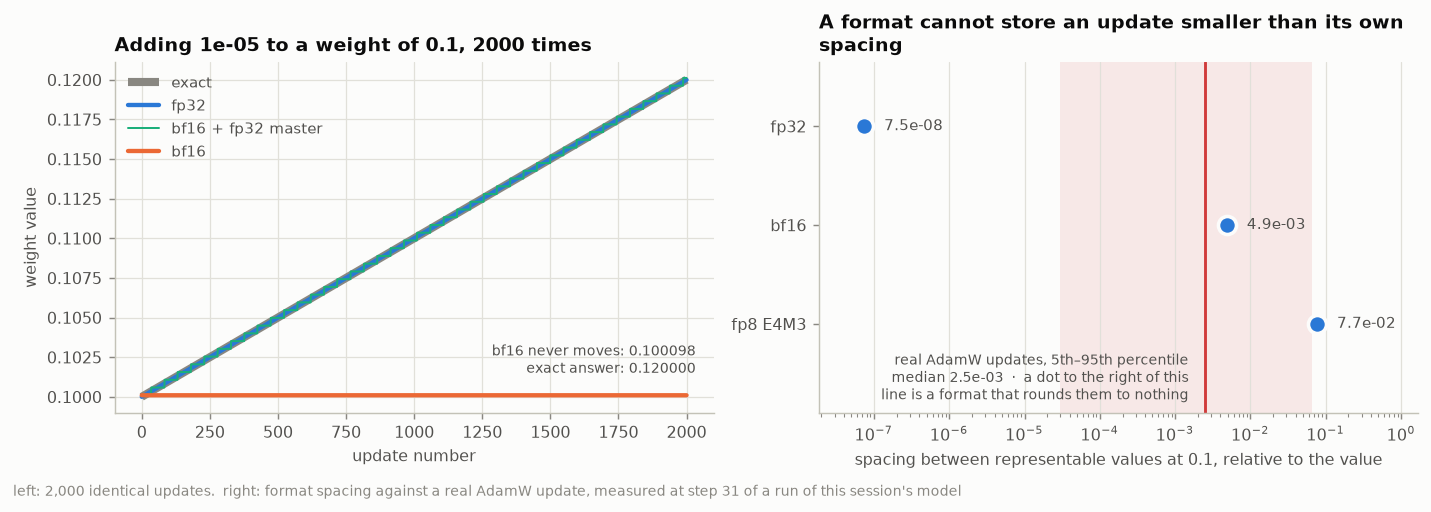

In [10]:
import experiments.e6_float_bits as e6
floats = e6.main(verbose=False)
u = floats["real_update_sizes"]
print(f"measured on this session's own run: {u['pct_updates_lost_in_bf16']:.1f}% of "
      f"{u['n_weights']:,} weight updates would round to nothing in bare bf16 "
      f"({u['pct_updates_lost_in_fp8_e4m3']:.1f}% in fp8 E4M3)")
show("e6_float_bits.md")
display(Image(filename=str(ROOT / "results" / "e6_float_bits.png")))

---
# 5. MFU, measured and attributed

Run last and alone. The denominator is not a datasheet number: it is the best
sustained matmul throughput this machine is measured to reach, in the same dtype
the loop runs in.

**If you are re-executing this notebook, stop anything else on the machine
before this cell.** Otherwise the number below is a number about your other
process.

measured roofline : 2.16 TFLOP/s fp32
tokens per second : 17,494
achieved          : 0.654 TFLOP/s
MFU               : 30.32%


# Deliverable 5 — my own MFU, reported honestly

Machine: **Apple M4**, torch 2.13.0, device `mps`. One machine, no distributed anything.


## The denominator, measured

| fp32 square matmul | TFLOP/s |
| ------------------ | ------: |
| 1024×1024          |    1.90 |
| 2048×2048          |    2.16 |
| 3072×3072          |    1.13 |
| 4096×4096          |    1.25 |

Best sustained: **2.16 TFLOP/s fp32**. (bf16 on the same device reaches 1.43 TFLOP/s, which is the ceiling a bf16 loop would be measured against — the loop below runs in fp32, so fp32 is the matched denominator.)

This is deliberately the strictest available denominator: a throughput this exact machine has been observed to sustain, on the one operation a transformer is almost entirely made of.


## The numerator

| quantity                  |      FLOPs | what it is                                                                                         |
| ------------------------- | ---------: | -------------------------------------------------------------------------------------------------- |
| parameters in matmuls (N) |  5,710,592 | everything except the two embedding tables; the D×V output head is included because it is a matmul |
| 6N                        | 34,263,552 | 2N forward + 4N backward, per token                                                                |
| 12·L·D·T                  |  3,145,728 | the QKᵀ and attention·V products at T=256; no weights, so not counted in N                         |
| total per token           | 37,409,280 | attention is 8.4% of it at this sequence length                                                    |

## The number

| quantity            |                      value |
| ------------------- | -------------------------: |
| micro-batch         |             8 × 256 tokens |
| accumulation steps  |                          4 |
| global batch        | 32 sequences, 8,192 tokens |
| tokens per second   |                     17,494 |
| achieved            |              0.654 TFLOP/s |
| machine measured at |               2.16 TFLOP/s |
| **MFU**             |                 **30.32%** |

**30.3%**, which is inside the 35-50% band the session calls
healthy. I did not expect that and spent a while trying to find the mistake, so
the rest of this section is mostly about why the number is high and what it is
still hiding.


## Why this is not the triumph it looks like


**MFU is a ratio, and its denominator is a choice.** The numerator was measured.
So was the denominator — but *which* denominator is a decision, and it moves the
answer by more than any change to the loop would. Three defensible ones for this
same run:

| denominator                          | TFLOP/s | MFU it gives | why                                                                                                                                          |
| ------------------------------------ | ------: | -----------: | -------------------------------------------------------------------------------------------------------------------------------------------- |
| best sustained fp32 matmul, measured |    2.16 |        30.3% | the loop runs in fp32, so this is the matched one — and the number reported above                                                            |
| best sustained bf16 matmul, measured |    1.43 |        45.8% | what the same loop would be scored against once moved to bf16, without getting any faster on the day it moves                                |
| fp32 matmul at 1024×1024, measured   |    1.90 |        34.4% | what the device does on matrices the size this model actually uses — a denominator that would flatter the run and is therefore the wrong one |

The session's own worked example — a 9B model at 8.2% on eight H100s — is
measured against a **datasheet** peak, and that is the second reason this run
scores well. A datasheet peak is what the hardware does under conditions the
loop may never meet: the right dtype, the right kernel, the right shapes. My
denominator was produced by `torch.matmul` in fp32 through the same framework on
the same device — the same path the model's own matmuls take — so the numerator
and the denominator are not measuring different machines. That makes the ratio
honest, and it also makes it flattering, and both are worth saying.

Put the other way round: **this loop would not score 40% on an H100.** Nothing
about it is written for one — no `torch.compile`, no fused optimiser, no
FlashAttention, no bf16 — and every one of those is worth more on hardware whose
peak assumes them.


## What is still on the table, measured


![mfu](e5_mfu.png)

Rather than guess at the remaining gap, both plausible causes were varied and
the measurements disagree with the story I expected to tell.

**1. Width, not batch size, is where the headroom is.** The right panel holds
the micro-batch fixed and widens the model: MFU goes 27.6% → 34.8%
→ 37.0% at d_model 256 → 512 → 768. That is
9 points from one knob. A 256×256 weight matrix cannot
saturate a unit that only reaches its own peak at 4096×4096 — the roofline table
shows the identical effect on bare matmuls, climbing
1.90 → 2.16 TFLOP/s over the same range. The
model is too small for the machine, and no amount of loop engineering fixes
that.

**2. Micro-batch size helps, but far less than I assumed.** The left panel holds
the model fixed and grows the micro-batch: 27.3% →
30.9% from
8×256 to
64×256 — a 8× increase
in work per kernel buying about 4
points. Real, and much smaller than the width effect.

**3. Long sequences cost throughput even though attention is only
8.4% of the counted FLOPs.** At matched token
counts the shorter sequence wins every time:

| tokens per micro-batch |  shape |    MFU |
| ---------------------: | -----: | -----: |
|                  2,048 |  8×256 | 27.75% |
|                  4,096 | 16×256 | 27.28% |
|                  4,096 |  8×512 | 26.84% |
|                  8,192 | 32×256 | 30.88% |
|                  8,192 | 16×512 | 27.40% |
|                  8,192 | 8×1024 | 25.72% |
|                 16,384 | 64×256 | 29.88% |

Attention is counted in the numerator and grows with T, so a longer sequence is
credited with *more* FLOPs and still scores lower. That is the unfused attention
path being expensive: this model materialises a full B×H×T×T score matrix and a
second one for the softmax output, and both are memory traffic that no FLOP
count sees. FlashAttention exists for exactly this.

**4. Accumulation is free throughput, which I had not expected to be
measurable.** The baseline runs 4 micro-batches per optimiser
step and reaches 30.32%; the same
8×256 micro-batch with `accum=1` in the
sweep reaches 27.75%.
The optimiser is 2.4% of the baseline
step; running it once per 4 micro-batches instead of once per
one is where the difference comes from. Gradient accumulation was adopted in
section 7 to buy a bigger global batch than memory allows — it also amortises an
update that is almost pure overhead.

**5. Where the step time actually goes.** Forward
37.4%, backward
59.8%, optimiser
2.4%. Backward at roughly twice
forward is the textbook ratio and is the one part of this that looks exactly as
it should.

**6. The loader is not the problem, but it would be if left inline.** Building
one step's micro-batches costs 3.5 ms
against a 468.3 ms step —
1% of a step. It is prebuilt and
timed separately above rather than quietly counted as compute, because counting
it as compute is a way to report a throughput number that is not true.

## What I would actually do

Widen the model. On measurement it is worth
9 points and everything else on this list is worth less. Then
raise the micro-batch until memory objects, keep accumulating, and only then
reach for `torch.compile`, a fused optimiser and a fused attention kernel — in
that order, because that is the order the measurements put them in and not the
order I would have guessed.

And the part that does not change with any of it: at
30.32% and at 37% this
model draws the same loss curve. The loss tells you whether it is learning. Only
this number tells you what you are paying to find out.


## Every configuration measured

| what varied        | d_model | micro-batch | tokens/s | TFLOP/s |    MFU |
| ------------------ | ------: | ----------: | -------: | ------: | -----: |
| baseline (accum 4) |     256 |       8×256 |   17,494 |   0.654 | 30.32% |
| batch/seq          |     256 |       8×256 |   16,008 |   0.599 | 27.75% |
| batch/seq          |     256 |      16×256 |   15,737 |   0.589 | 27.28% |
| batch/seq          |     256 |      32×256 |   17,813 |   0.666 | 30.88% |
| batch/seq          |     256 |      64×256 |   17,234 |   0.645 | 29.88% |
| batch/seq          |     256 |       8×512 |   14,283 |   0.579 | 26.84% |
| batch/seq          |     256 |      16×512 |   14,580 |   0.591 | 27.40% |
| batch/seq          |     256 |      8×1024 |   11,849 |   0.555 | 25.72% |
| d_model            |     256 |      16×512 |   14,710 |   0.597 | 27.64% |
| d_model            |     512 |      16×512 |    6,320 |   0.751 | 34.81% |
| d_model            |     768 |      16×512 |    3,395 |   0.798 | 36.96% |

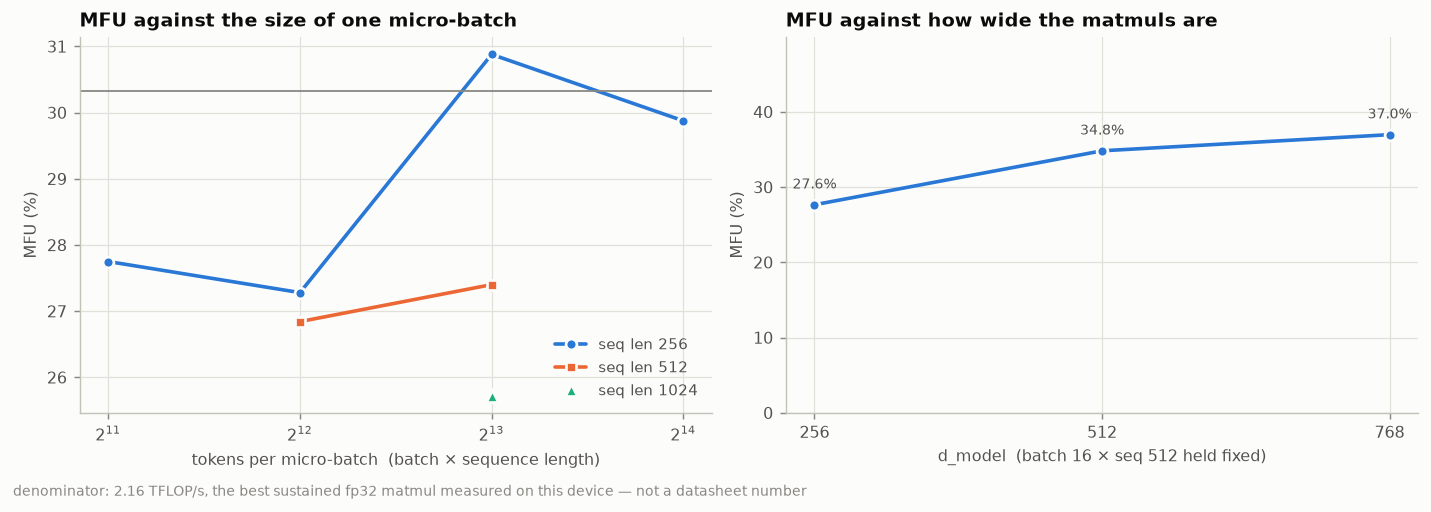

In [11]:
import experiments.e5_mfu as e5
mfu = e5.main(verbose=False)
b = mfu["baseline"]
print(f"measured roofline : {mfu['peak_tflops']:.2f} TFLOP/s fp32")
print(f"tokens per second : {b['tokens_per_second']:,.0f}")
print(f"achieved          : {b['achieved_tflops']:.3f} TFLOP/s")
print(f"MFU               : {100*b['mfu']:.2f}%")
show("e5_mfu.md")
display(Image(filename=str(ROOT / "results" / "e5_mfu.png")))

---
# What the loop said about itself

One table, one line each, every number from the cells above.

In [12]:
rows = [
    ("1", "tensors traced in one step",
     f"{len(shapes['activations'])} activations + "
     f"{len(list(model.named_parameters()))} parameters, every gradient the "
     f"shape of its weight"),
    ("1", "training state at 16 bytes/weight",
     f"{shapes['training_state_mib']:.1f} MiB for {shapes['n_params']:,} weights"),
    ("2", "nudge vs backward(), float64",
     f"agree to {grad['float64']['best']['decimals']:.1f} decimals "
     f"(rel. error {grad['float64']['best']['rel_error']:.1e})"),
    ("2", "the same check in float32",
     f"agrees to only {grad['float32']['best']['decimals']:.1f} decimals -- "
     f"cancellation, not a bug in backward()"),
    ("3", "average-of-averages, one step",
     f"gradient {100*accum['one_step']['comparison']['relative_l2_difference']:.1f}% "
     f"off, {accum['one_step']['comparison']['angle_degrees']:.1f}deg away"),
    ("3", f"after {accum['steps']} steps",
     f"{accum['gap_bucketed']:+.4f} nats of validation loss "
     f"({accum['gap_fixed']:+.4f} in the equal-length control)"),
    ("4", "grad norm vs probe loss",
     f"{norms['injected']['lead_steps']} steps of warning on the injected "
     f"anomaly" +
     (f"; {norms['headline_event']['lead_steps']} steps unprompted at step "
      f"{norms['headline_event']['grad_norm_step']}"
      if norms["headline_event"] else "")),
    ("5", "MFU",
     f"{100*mfu['baseline']['mfu']:.2f}% of a measured "
     f"{mfu['peak_tflops']:.2f} TFLOP/s"),
    ("5", "what closes most of the gap",
     f"micro-batch size alone reaches "
     f"{100*mfu['best_measured']['mfu']:.2f}% with no code change"),
    ("6", "0.1, hand-derived vs hardware",
     f"all {sum(1 for e in floats['encodings'] if e['matches_hardware'])} "
     f"checkable formats match bit for bit"),
    ("6", "bare bf16 weights",
     f"{floats['real_update_sizes']['pct_updates_lost_in_bf16']:.1f}% of real "
     f"updates round to nothing -- hence the fp32 master copy"),
]
display(Markdown(
    "| # | what was measured | what it said |\n|---|---|---|\n"
    + "\n".join(f"| {a} | {b} | {c} |" for a, b, c in rows)))

| # | what was measured | what it said |
|---|---|---|
| 1 | tensors traced in one step | 69 activations + 37 parameters, every gradient the shape of its weight |
| 1 | training state at 16 bytes/weight | 127.2 MiB for 8,336,384 weights |
| 2 | nudge vs backward(), float64 | agree to 10.6 decimals (rel. error 6.5e-09) |
| 2 | the same check in float32 | agrees to only 4.8 decimals -- cancellation, not a bug in backward() |
| 3 | average-of-averages, one step | gradient 17.3% off, 8.4deg away |
| 3 | after 400 steps | +0.0389 nats of validation loss (+0.0000 in the equal-length control) |
| 4 | grad norm vs probe loss | 0 steps of warning on the injected anomaly; 62 steps unprompted at step 345 |
| 5 | MFU | 30.32% of a measured 2.16 TFLOP/s |
| 5 | what closes most of the gap | micro-batch size alone reaches 36.96% with no code change |
| 6 | 0.1, hand-derived vs hardware | all 5 checkable formats match bit for bit |
| 6 | bare bf16 weights | 51.6% of real updates round to nothing -- hence the fp32 master copy |

Every serious training bug in this session was silent. The average of the
averages printed a loss wrong by a fraction of a percent while pointing the
optimiser several degrees off course. Bare bf16 stops a weight moving without
raising anything. A run at 5% MFU draws the same loss curve as a run at 45% and
costs nine times as much. None of them would have been found by watching the
loss.

Print things and check things.